In [1]:
from datetime import datetime
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
# Path to the JSON files
data_dir = Path('../scraping/output_data/forum_posts/')

# Get all JSON files
json_files = list(data_dir.glob('*.json'))

print(f"Found {len(json_files)} JSON files")

# Load and concatenate all JSON files
all_data = []
for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        # Each JSON file contains a list of records
        all_data.extend(data)

# Create a single dataframe
df = pd.DataFrame(all_data)

print(f"Total records: {len(df)}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Found 357 JSON files
Total records: 550813

DataFrame shape: (550813, 9)

Columns: ['id', 'author_id', 'message', 'date_time', 'engagement', 'forum', 'url', 'company_name', 'ticker']

First few rows:


,id,author_id,message,date_time,engagement,forum,url,company_name,ticker
0,Sijoitustieto.comment-17873,Sijoitustieto.Unknown,Juha kirjoitti:\n\nAdmicom Oyj:n anti ylimerki...,2018-02-02T04:25:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
1,Sijoitustieto.comment-17885,Sijoitustieto.Unknown,Kiitos luottamuksesta Aki! Sijoitustiedon kesk...,2018-02-02T13:29:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
2,Sijoitustieto.comment-17889,Sijoitustieto.Unknown,Itselläni ollut käteisvarat vähän tavallista t...,2018-02-02T14:44:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
3,Sijoitustieto.comment-17941,Sijoitustieto.Unknown,"Oma veikkaus on, että yleisöannissa kaikki saa...",2018-02-04T17:16:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM
4,Sijoitustieto.comment-17960,Sijoitustieto.Unknown,"Googlen hakuanalyysi piti kutinsa, mutta olisi...",2018-02-05T14:33:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM


In [3]:
# Set up matplotlib style
plt.style.use('default')
%matplotlib inline

## Data Preprocessing

First, we'll clean the data by removing noise and filtering based on quality criteria.

In [4]:
import re

# Store original count
original_count = len(df)
print(f"Starting with {original_count:,} records")

# Convert date_time to datetime and remove timezone offset
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', utc=True)
# Convert to timezone-naive by removing the timezone info
df['date_time'] = df['date_time'].dt.tz_localize(None)

# Remove posts before 2013-01-01
cutoff_date = pd.Timestamp('2013-01-01')
df = df[df['date_time'] >= cutoff_date].copy()
print(f"After removing posts before 2013-01-01: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

# Remove URLs and HTML tags (keeping \n characters)
def clean_text(text):
    if pd.isna(text):
        return text
    # Remove URLs (http, https, www)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Clean up extra whitespace (but preserve \n)
    text = re.sub(r'[ \t]+', ' ', text)
    text = text.strip()
    return text

df['message'] = df['message'].apply(clean_text)
print(f"After cleaning URLs/HTML: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

# Remove posts with less than 20 characters, more than 3000 characters
df = df[df['message'].str.len() >= 20].copy()
print(f"After removing messages < 20 chars: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

df = df[df['message'].str.len() <= 3000].copy()
print(f"After removing messages with >3000 chars: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

# Remove posts that are duplicate across threads (same message content and author)
df = df.drop_duplicates(subset=['author_id', 'message']).copy()
print(f"After removing cross-thread duplicates: {len(df):,} records ({len(df)/original_count*100:.1f}% remaining)")

print(f"\n{'='*60}")
print(f"Total records removed: {original_count - len(df):,} ({(original_count - len(df))/original_count*100:.1f}%)")
print(f"Final record count: {len(df):,}")
print(f"{'='*60}")

Starting with 550,813 records
After removing posts before 2013-01-01: 545,601 records (99.1% remaining)
After cleaning URLs/HTML: 545,601 records (99.1% remaining)
After removing messages < 20 chars: 539,364 records (97.9% remaining)
After removing messages with >3000 chars: 534,534 records (97.0% remaining)
After removing cross-thread duplicates: 532,424 records (96.7% remaining)

Total records removed: 18,389 (3.3%)
Final record count: 532,424


In [5]:
# Show sample of cleaned messages
print("Sample cleaned messages:")
print("="*80)
for i, row in df.sample(6).iterrows():
    print(f"\nTicker: {row['ticker']}")
    print(f"\nForum: {row['forum']}")
    print(f"Date: {row['date_time']}")
    print(f"Message ({len(row['message'])} chars):")
    print(row['message'][:200] + "..." if len(row['message']) > 200 else row['message'])
    print("-"*80)

Sample cleaned messages:

Ticker: OLVAS

Forum: Kauppalehti
Date: 2016-10-27 21:19:14
Message (707 chars):
Olvihan on ollut 2000-luvulla suurimipia kasvajia Koneen ja
PKC Groupin kanssa, ja näistä jälkimmäinen nyt on laadultaan vähän mitä sattuu. Olvin kasvutarina ei ole vielä päättyynyt, uusille markkinoi...
--------------------------------------------------------------------------------

Ticker: NOKIA

Forum: Kauppalehti
Date: 2025-02-25 10:49:14
Message (30 chars):
Ericssonilla 3.06B osaketta...
--------------------------------------------------------------------------------

Ticker: HEALTH

Forum: Inderes
Date: 2021-04-21 16:25:43.604000
Message (351 chars):
Hyvin sanottu!

Jos liiketoimintamallina on pörriäisten kautta julkiselle sektorille, lähteekö pörriäiset? lähteekö julkinen sektori?

Sijoittamiseen liittyy aina riski, mutta tässä tapauksessa en pit...
--------------------------------------------------------------------------------

Ticker: SSABBH

Forum: Kauppalehti
Date: 20

## Exploratory Data Analysis

### 1. ID Column - Duplicate Check

In [6]:
# Check for duplicate IDs
total_ids = len(df['id'])
unique_ids = df['id'].nunique()
duplicate_count = total_ids - unique_ids

print(f"Total IDs: {total_ids:,}")
print(f"Unique IDs: {unique_ids:,}")
print(f"Duplicate IDs: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count/total_ids)*100:.2f}%")

if duplicate_count > 0:
    print(f"\nSample duplicates:")
    duplicates = df[df.duplicated(subset=['id'], keep=False)].sort_values('id')
    print(duplicates[['id', 'company_name', 'ticker', 'date_time']].head(10))

Total IDs: 532,424
Unique IDs: 532,424
Duplicate IDs: 0
Duplicate percentage: 0.00%


### 2. Message Length Statistics

Message Length Statistics:
--------------------------------------------------
min                 : 20 characters
max                 : 3,000 characters
mean                : 461 characters
median              : 318 characters
mode                : 62 characters
25th percentile     : 159 characters
50th percentile     : 318 characters
75th percentile     : 599 characters
90th percentile     : 1,020 characters
99th percentile     : 2,265 characters


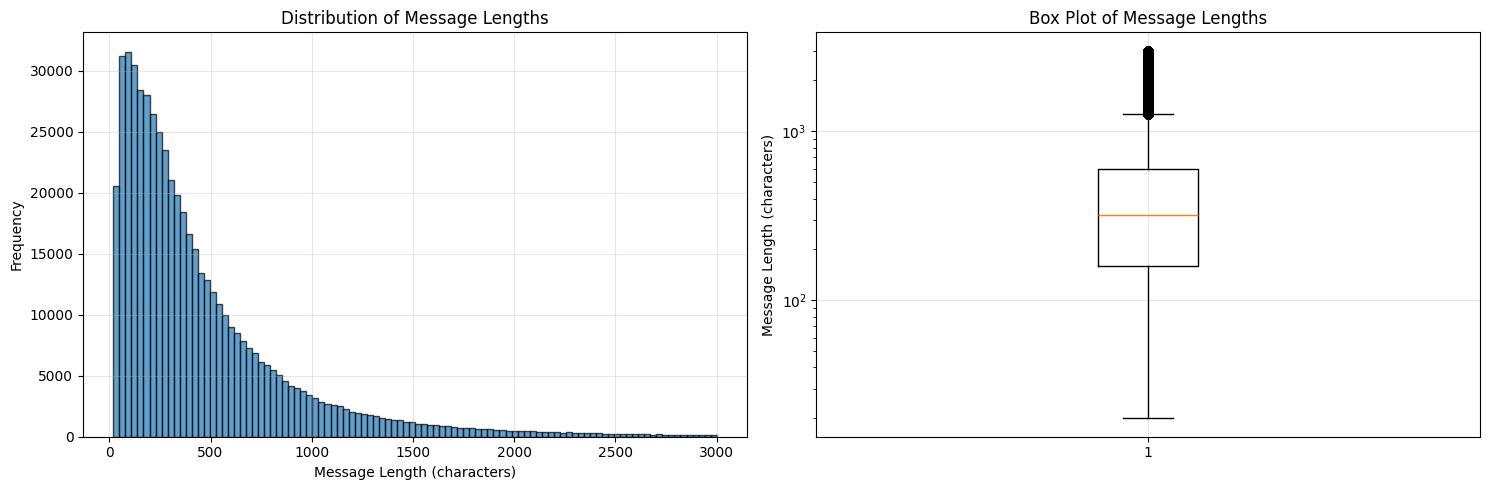

In [7]:
# Calculate message lengths
df['message_length'] = df['message'].str.len()

# Calculate statistics
msg_stats = {
    'min': df['message_length'].min(),
    'max': df['message_length'].max(),
    'mean': df['message_length'].mean(),
    'median': df['message_length'].median(),
    'mode': df['message_length'].mode()[0] if len(df['message_length'].mode()) > 0 else None,
    '25th percentile': df['message_length'].quantile(0.25),
    '50th percentile': df['message_length'].quantile(0.50),
    '75th percentile': df['message_length'].quantile(0.75),
    '90th percentile': df['message_length'].quantile(0.90),
    '99th percentile': df['message_length'].quantile(0.99),
}

print("Message Length Statistics:")
print("-" * 50)
for key, value in msg_stats.items():
    print(f"{key:20s}: {value:,.0f} characters")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['message_length'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Message Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Message Lengths')
axes[0].grid(True, alpha=0.3)

# Box plot (log scale for better visualization)
axes[1].boxplot(df['message_length'], vert=True)
axes[1].set_ylabel('Message Length (characters)')
axes[1].set_title('Box Plot of Message Lengths')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Date-Time Analysis

Date Range:
  Earliest message: 2013-01-02 08:59:01
  Latest message:   2025-12-18 07:42:36.068000
  Time span:        4732 days (13.0 years)


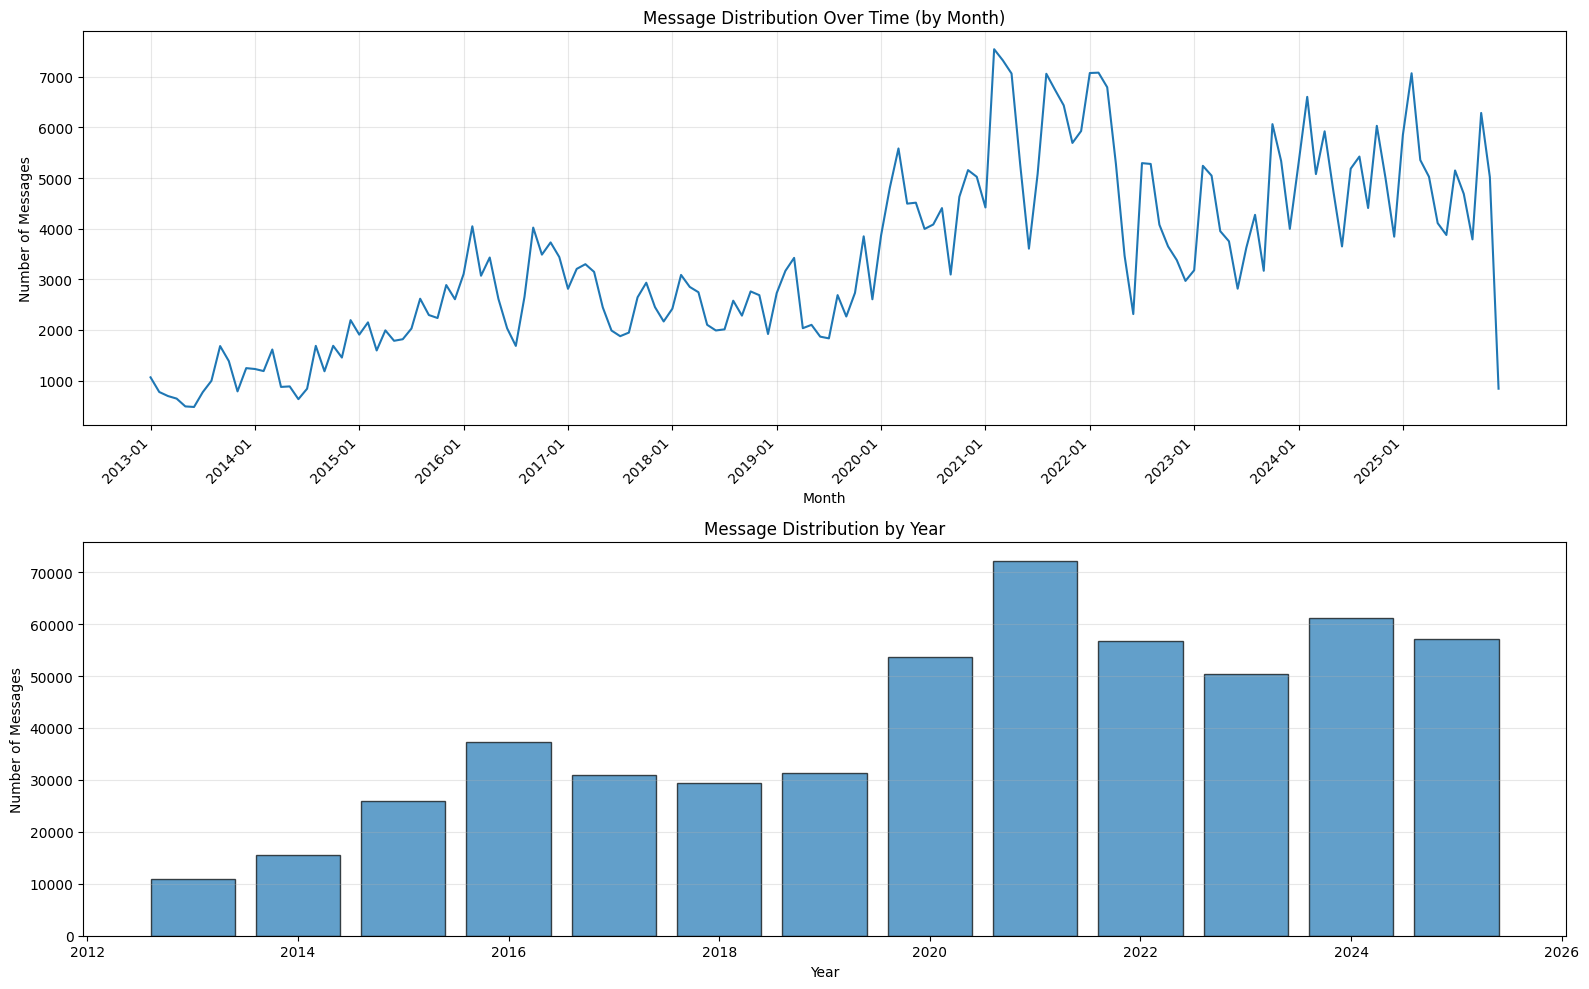


Top 10 Most Active Months:
    year_month  count
97     2021-02   7544
98     2021-03   7324
109    2022-02   7081
108    2022-01   7074
145    2025-02   7069
99     2021-04   7064
103    2021-08   7059
110    2022-03   6793
104    2021-09   6742
133    2024-02   6603


In [8]:
# Min and Max dates
min_date = df['date_time'].min()
max_date = df['date_time'].max()

print(f"Date Range:")
print(f"  Earliest message: {min_date}")
print(f"  Latest message:   {max_date}")
print(f"  Time span:        {(max_date - min_date).days} days ({(max_date - min_date).days/365.25:.1f} years)")

# Extract year-month for grouping
df['year_month'] = df['date_time'].dt.to_period('M')

# Count messages by month
monthly_counts = df.groupby('year_month').size().reset_index(name='count')
monthly_counts['year_month'] = monthly_counts['year_month'].astype(str)

# Plot distribution by month
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Time series plot
axes[0].plot(range(len(monthly_counts)), monthly_counts['count'], linewidth=1.5)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Messages')
axes[0].set_title('Message Distribution Over Time (by Month)')
axes[0].grid(True, alpha=0.3)
# Show every 12th label (yearly)
tick_positions = range(0, len(monthly_counts), 12)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels([monthly_counts['year_month'].iloc[i] if i < len(monthly_counts) else '' 
                          for i in tick_positions], rotation=45, ha='right')

# Histogram by year
df['year'] = df['date_time'].dt.year
yearly_counts = df.groupby('year').size()
axes[1].bar(yearly_counts.index, yearly_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Messages')
axes[1].set_title('Message Distribution by Year')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTop 10 Most Active Months:")
print(monthly_counts.sort_values('count', ascending=False).head(10))

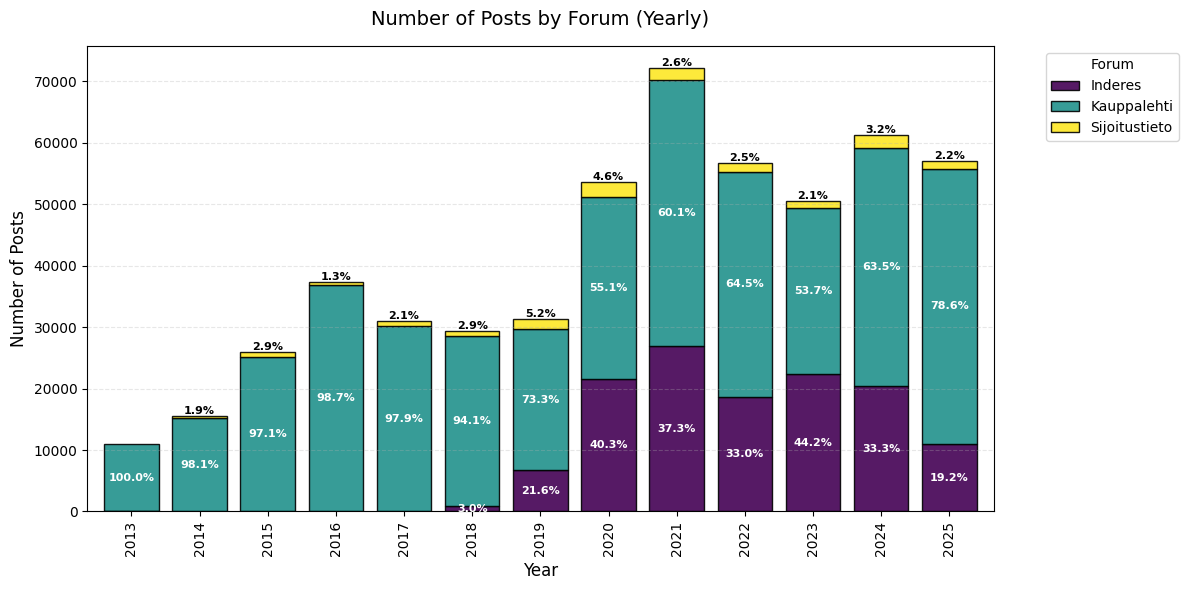


Share of posts by forum (percentage):
forum  Inderes  Kauppalehti  Sijoitustieto
year                                      
2013      0.00       100.00           0.00
2014      0.00        98.13           1.87
2015      0.00        97.07           2.93
2016      0.00        98.70           1.30
2017      0.00        97.86           2.14
2018      2.98        94.13           2.89
2019     21.55        73.27           5.17
2020     40.32        55.10           4.59
2021     37.26        60.13           2.61
2022     32.97        64.52           2.51
2023     44.24        53.66           2.10
2024     33.30        63.48           3.22
2025     19.20        78.60           2.20


In [14]:
# Calculate shares of posts per forum per year
if 'year' not in df.columns:
    df['year'] = df['date_time'].dt.year

# Pivot table to get counts by year and forum
forum_yearly_counts = df.groupby(['year', 'forum']).size().unstack(fill_value=0)

# Calculate percentage share
forum_yearly_shares = forum_yearly_counts.div(forum_yearly_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart with counts on y-axis and percentage labels inside bars
fig, ax = plt.subplots(figsize=(12, 6))
forum_yearly_counts.plot(kind='bar', stacked=True, ax=ax,
                        colormap='viridis', alpha=0.9, edgecolor='black', width=0.8)

# Add percentage labels inside each bar segment
for i, year in enumerate(forum_yearly_counts.index):
    cumulative = 0
    for j, forum in enumerate(forum_yearly_counts.columns):
        count = forum_yearly_counts.loc[year, forum]
        pct = forum_yearly_shares.loc[year, forum]
        if count > 0:
            if forum == 'Sijoitustieto':
                # Place label above the bar for Sijoitustieto (small segment at top)
                ax.text(i, cumulative + count, f'{pct:.1f}%',
                        ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')
            else:
                ax.text(i, cumulative + count / 2, f'{pct:.1f}%',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        cumulative += count

ax.set_title('Number of Posts by Forum (Yearly)', fontsize=14, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Posts', fontsize=12)
ax.legend(title='Forum', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print values
print("\nShare of posts by forum (percentage):")
print(forum_yearly_shares.round(2))

In [17]:
# Overall share of posts by forum
overall_counts = df['forum'].value_counts()
overall_share = (overall_counts / overall_counts.sum() * 100).round(2)

summary = pd.DataFrame({
    'Posts': overall_counts,
    'Share (%)': overall_share
})
summary.loc['Total'] = [overall_counts.sum(), 100.0]
summary['Posts'] = summary['Posts'].astype(int)
print(summary.to_string())

                Posts  Share (%)
forum                           
Kauppalehti    389258      73.11
Inderes        128449      24.13
Sijoitustieto   14717       2.76
Total          532424     100.00


### 4. Engagement Analysis

Engagement Statistics:
  Non-null values: 532,424 (100.00%)
  Null values:     0 (0.00%)

Top 10 Most Common Engagement Values:
   1. 'N/A': 341,740 occurrences (64.19%)
   2. '1': 13,265 occurrences (2.49%)
   3. '0': 12,931 occurrences (2.43%)
   4. '2': 11,599 occurrences (2.18%)
   5. '3': 9,983 occurrences (1.88%)
   6. '4': 8,579 occurrences (1.61%)
   7. '5': 7,390 occurrences (1.39%)
   8. '6': 6,449 occurrences (1.21%)
   9. '7': 5,534 occurrences (1.04%)
  10. '8': 4,853 occurrences (0.91%)


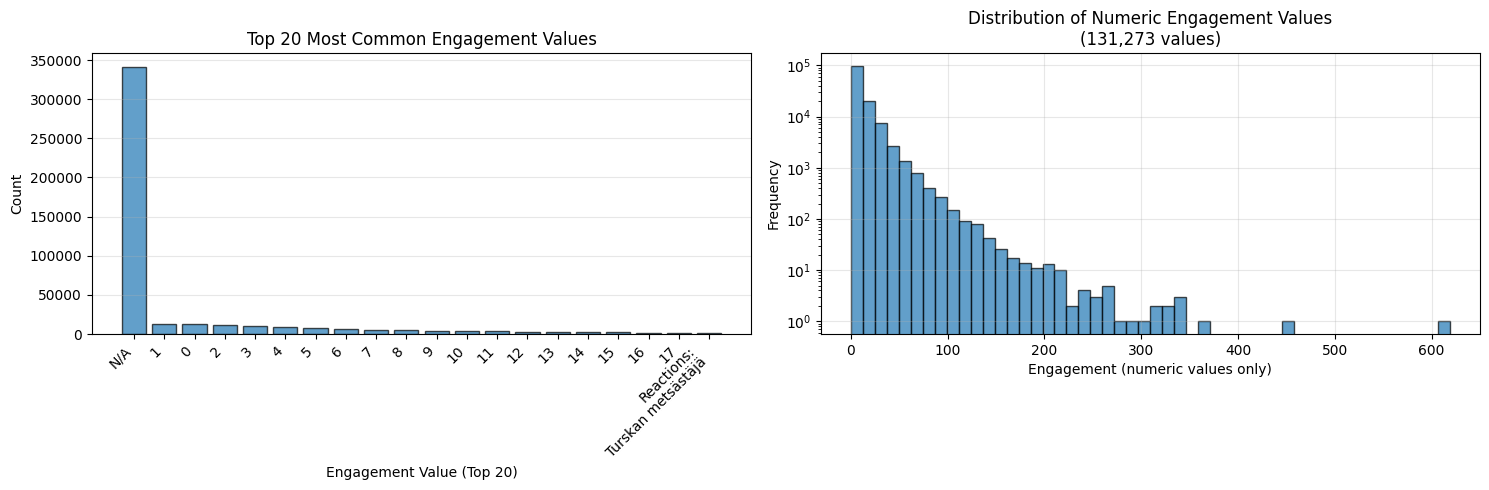

In [56]:
# Engagement analysis
non_null_engagement = df['engagement'].notna().sum()
total_engagement = len(df)

print(f"Engagement Statistics:")
print(f"  Non-null values: {non_null_engagement:,} ({non_null_engagement/total_engagement*100:.2f}%)")
print(f"  Null values:     {total_engagement - non_null_engagement:,} ({(total_engagement - non_null_engagement)/total_engagement*100:.2f}%)")

# Top 10 most common engagement values
print(f"\nTop 10 Most Common Engagement Values:")
top_engagement = df['engagement'].value_counts().head(10)
for idx, (value, count) in enumerate(top_engagement.items(), 1):
    print(f"  {idx:2d}. '{value}': {count:,} occurrences ({count/total_engagement*100:.2f}%)")

# Plot engagement distribution (for numeric convertible values)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of top 20 values
top_20 = df['engagement'].value_counts().head(20)
axes[0].bar(range(len(top_20)), top_20.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Engagement Value (Top 20)')
axes[0].set_ylabel('Count')
axes[0].set_title('Top 20 Most Common Engagement Values')
axes[0].set_xticks(range(len(top_20)))
axes[0].set_xticklabels(top_20.index, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Try to convert to numeric for distribution plot
df['engagement_numeric'] = pd.to_numeric(df['engagement'], errors='coerce')
numeric_engagement = df['engagement_numeric'].dropna()

if len(numeric_engagement) > 0:
    axes[1].hist(numeric_engagement, bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Engagement (numeric values only)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Numeric Engagement Values\n({len(numeric_engagement):,} values)')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')
else:
    axes[1].text(0.5, 0.5, 'No numeric engagement values found', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 5. Ticker Analysis

In [57]:
# Ticker analysis
unique_tickers = df['ticker'].nunique()
total_messages = len(df)

print(f"Ticker Statistics:")
print(f"  Unique tickers:    {unique_tickers:,}")
print(f"  Total messages:    {total_messages:,}")
print(f"  Avg messages/ticker: {total_messages/unique_tickers:.1f}")

# Distribution of messages per ticker
messages_per_ticker = df['ticker'].value_counts()
print(f"\nMessages per Ticker Distribution:")
print(f"  Min:    {messages_per_ticker.min():,} messages")
print(f"  Max:    {messages_per_ticker.max():,} messages")
print(f"  Mean:   {messages_per_ticker.mean():.1f} messages")
print(f"  Median: {messages_per_ticker.median():.0f} messages")

print(f"\nTop 10 Most Discussed Tickers:")
for idx, (ticker, count) in enumerate(messages_per_ticker.head(10).items(), 1):
    company = df[df['ticker'] == ticker]['company_name'].iloc[0]
    print(f"  {idx:2d}. {ticker:10s} ({company:30s}): {count:,} messages")

print(f"\nBottom 10 Least Discussed Tickers:")
for idx, (ticker, count) in enumerate(messages_per_ticker.tail(10).items(), 1):
    company = df[df['ticker'] == ticker]['company_name'].iloc[0]
    print(f"  {idx:2d}. {ticker:10s} ({company:30s}): {count:,} messages")

Ticker Statistics:
  Unique tickers:    162
  Total messages:    532,424
  Avg messages/ticker: 3286.6

Messages per Ticker Distribution:
  Min:    7 messages
  Max:    38,749 messages
  Mean:   3286.6 messages
  Median: 1096 messages

Top 10 Most Discussed Tickers:
   1. BIOBV      (Biohit                        ): 38,749 messages
   2. NOKIA      (Nokia                         ): 24,784 messages
   3. FORTUM     (Fortum                        ): 17,922 messages
   4. FIA1S      (Finnair                       ): 17,920 messages
   5. CTH1V      (Componenta                    ): 17,326 messages
   6. SSABBH     (SSAB                          ): 16,029 messages
   7. REG1V      (Revenio                       ): 15,625 messages
   8. TYRES      (Nokian Renkaat                ): 15,123 messages
   9. AFAGR      (Afarak                        ): 14,516 messages
  10. BITTI      (Bittium                       ): 13,999 messages

Bottom 10 Least Discussed Tickers:
   1. PIIPPO     (Piippo   

### 6. Financial Data Import and Linkage Check

In [ ]:
# Import all Yahoo Finance CSV files
financial_data_dir = Path('../scraping/output_data/')

# Get all Yahoo Finance CSV files
csv_files = list(financial_data_dir.glob('yahoofinance_*.csv'))

print(f"Found {len(csv_files)} financial data CSV files")

# Load all CSV files and add ticker column
financial_dfs = []

for csv_file in csv_files:
    # Extract ticker from filename: yahoofinance_{ticker}.csv
    ticker = csv_file.stem.split('_', 1)[1]  # Get everything after first underscore
    
    try:
        df_financial = pd.read_csv(csv_file)
        df_financial['ticker'] = ticker
        financial_dfs.append(df_financial)
    except Exception as e:
        print(f"Error loading {csv_file.name}: {e}")

if financial_dfs:
    # Concatenate all financial data
    financial_data = pd.concat(financial_dfs, ignore_index=True)
    print(f"\nTotal financial data rows: {len(financial_data):,}")
    print(f"Unique tickers in financial data: {financial_data['ticker'].nunique()}")
    print(f"\nFinancial data columns: {financial_data.columns.tolist()}")
    print(f"\nSample financial data:")
    display(financial_data.head())
else:
    print("No financial data loaded")
    financial_data = pd.DataFrame()

Found 0 financial data CSV files
No financial data loaded


In [59]:
# Check if all posts have corresponding financial data
if not financial_data.empty:
    # Get unique tickers from posts
    post_tickers = set(df['ticker'].unique())
    
    # Get unique tickers from financial data
    financial_tickers = set(financial_data['ticker'].unique())
    
    print(f"Ticker Coverage Analysis:")
    print(f"{'='*60}")
    print(f"Unique tickers in posts:         {len(post_tickers):,}")
    print(f"Unique tickers in financial data: {len(financial_tickers):,}")
    
    # Find posts with financial data
    posts_with_financial = post_tickers.intersection(financial_tickers)
    print(f"\nTickers with both posts and financial data: {len(posts_with_financial):,} ({len(posts_with_financial)/len(post_tickers)*100:.1f}%)")
    
    # Find posts without financial data
    posts_without_financial = post_tickers - financial_tickers
    if posts_without_financial:
        print(f"\nTickers with posts but NO financial data: {len(posts_without_financial):,}")
        print(f"Sample tickers without financial data:")
        for ticker in sorted(list(posts_without_financial))[:10]:
            company = df[df['ticker'] == ticker]['company_name'].iloc[0]
            count = len(df[df['ticker'] == ticker])
            print(f"  - {ticker:10s} ({company:30s}): {count:,} posts")
    else:
        print(f"\n✓ All post tickers have corresponding financial data!")
    
    # Find financial data without posts
    financial_without_posts = financial_tickers - post_tickers
    if financial_without_posts:
        print(f"\nTickers with financial data but NO posts: {len(financial_without_posts):,}")
        print(f"Sample: {sorted(list(financial_without_posts))[:10]}")
    
    # Create a summary dataframe
    ticker_summary = []
    for ticker in sorted(post_tickers):
        company = df[df['ticker'] == ticker]['company_name'].iloc[0]
        post_count = len(df[df['ticker'] == ticker])
        has_financial = ticker in financial_tickers
        financial_rows = len(financial_data[financial_data['ticker'] == ticker]) if has_financial else 0
        
        ticker_summary.append({
            'ticker': ticker,
            'company': company,
            'post_count': post_count,
            'has_financial_data': has_financial,
            'financial_data_rows': financial_rows
        })
    
    ticker_summary_df = pd.DataFrame(ticker_summary)
    
    print(f"\n{'='*60}")
    print(f"Summary Statistics:")
    print(f"  Tickers with financial data: {ticker_summary_df['has_financial_data'].sum():,}")
    print(f"  Tickers without financial data: {(~ticker_summary_df['has_financial_data']).sum():,}")
    print(f"  Total posts linked to financial data: {ticker_summary_df[ticker_summary_df['has_financial_data']]['post_count'].sum():,}")
    print(f"  Total posts NOT linked to financial data: {ticker_summary_df[~ticker_summary_df['has_financial_data']]['post_count'].sum():,}")
    
    print(f"\nTop 10 tickers by post count (with financial data status):")
    display(ticker_summary_df.sort_values('post_count', ascending=False).head(10))
else:
    print("Cannot perform linkage check - no financial data loaded")

Cannot perform linkage check - no financial data loaded


## Output

In [60]:
df.head(20)

,id,author_id,message,date_time,engagement,forum,url,company_name,ticker,message_length,year_month,year,engagement_numeric
0,Sijoitustieto.comment-17873,Sijoitustieto.Unknown,Juha kirjoitti:\n\nAdmicom Oyj:n anti ylimerki...,2018-02-02 04:25:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,484,2018-02,2018,NaN
1,Sijoitustieto.comment-17885,Sijoitustieto.Unknown,Kiitos luottamuksesta Aki! Sijoitustiedon kesk...,2018-02-02 13:29:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,733,2018-02,2018,NaN
2,Sijoitustieto.comment-17889,Sijoitustieto.Unknown,Itselläni ollut käteisvarat vähän tavallista t...,2018-02-02 14:44:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,535,2018-02,2018,NaN
3,Sijoitustieto.comment-17941,Sijoitustieto.Unknown,"Oma veikkaus on, että yleisöannissa kaikki saa...",2018-02-04 17:16:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,249,2018-02,2018,NaN
4,Sijoitustieto.comment-17960,Sijoitustieto.Unknown,"Googlen hakuanalyysi piti kutinsa, mutta olisi...",2018-02-05 14:33:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,790,2018-02,2018,NaN
5,Sijoitustieto.comment-18035,Sijoitustieto.Unknown,"Tämä meni sinänsä hyvin, että ymmärsin merkitä...",2018-02-08 10:49:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,761,2018-02,2018,NaN
6,Sijoitustieto.comment-18061,Sijoitustieto.Unknown,"Vanha totuus on, että kun pienen annin myy vai...",2018-02-09 10:08:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,300,2018-02,2018,NaN
7,Sijoitustieto.comment-18062,Sijoitustieto.Unknown,"Nyt 10% ylhäällä, yllättävän hyvin se kuitenki...",2018-02-09 10:34:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,428,2018-02,2018,NaN
8,Sijoitustieto.comment-18066,Sijoitustieto.Unknown,Kohtalainen nousu tosiaan. Itsellä jää tuo min...,2018-02-09 12:05:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,134,2018-02,2018,NaN
9,Sijoitustieto.comment-18096,Sijoitustieto.Unknown,"Mie panin firmojen Admicomit lihoiksi @11,00. ...",2018-02-12 10:12:00,N/A,Sijoitustieto,https://www.sijoitustieto.fi/sijoituskeskustel...,Admicom,ADMCM,324,2018-02,2018,NaN


In [ ]:
df.to_csv("./data/cleaned_forum_posts.csv")

In [ ]:
df.to_pickle("./data/cleaned_forum_posts.pkl")